In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#import warnings
#warnings.filterwarnings("ignore")

In [30]:
df = pd.read_excel('omar_lk_stat.xlsx')
df.head()

,Date,Impressions,Interactions,Nouveaux abonnés
0,01/08/2023,11,1,4
1,02/08/2023,8,0,0
2,03/08/2023,12,0,2
3,04/08/2023,3,0,3
4,05/08/2023,10,0,0


In [32]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [33]:
df.head()

,Date,Impressions,Interactions,Nouveaux abonnés
0,2023-08-01,11,1,4
1,2023-08-02,8,0,0
2,2023-08-03,12,0,2
3,2023-08-04,3,0,3
4,2023-08-05,10,0,0


In [34]:
df.set_index('Date', inplace=True)

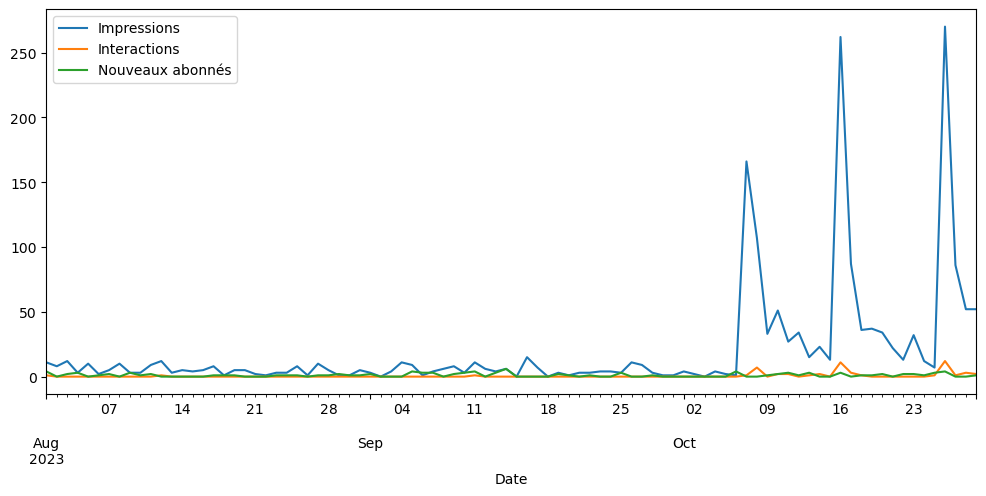

In [37]:
df.plot(figsize=(12,5));

In [38]:
nv = pd.DataFrame(df['Nouveaux abonnés'])

In [39]:
nv.head()

,Nouveaux abonnés
Date,
2023-08-01,4
2023-08-02,0
2023-08-03,2
2023-08-04,3
2023-08-05,0


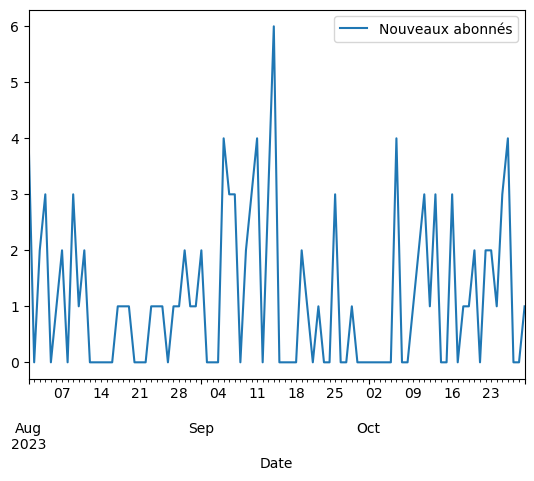

In [45]:
nv.plot();

In [40]:
nv.shape

(90, 1)

In [41]:
import pmdarima as pmd

In [43]:
Ntest = 15
train = nv.iloc[:-Ntest]
test = nv.iloc[-Ntest:]

In [48]:
model = pmd.auto_arima(train, error_action='ignore', trace=True, supress_warning=True, max_p=12, max_q=2, max_order=14,
                     stepwise=False, seasonal=False)

 ARIMA(0,0,0)(0,0,0)[0]             : AIC=298.885, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=289.720, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=289.503, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=284.837, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=270.199, Time=0.06 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=272.154, Time=0.06 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=282.561, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=272.171, Time=0.06 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.19 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=277.648, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=272.755, Time=0.08 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=274.114, Time=0.20 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=277.098, Time=0.05 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=274.680, Time=0.09 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=0.32 sec
 ARIMA(5,0,0)(0,0,0)[0]          

In [49]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   75
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -132.099
Date:                Sun, 29 Oct 2023   AIC                            270.199
Time:                        21:51:21   BIC                            277.151
Sample:                    08-01-2023   HQIC                           272.975
                         - 10-14-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9845      0.021     46.209      0.000       0.943       1.026
ma.L1         -0.8374      0.083    -10.094      0.000      -1.000      -0.675
sigma2         1.9515      0.314      6.214      0.000       1.336       2.567
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 8.55
Prob(Q):                              0.72   Prob(JB):                         0.01
Heteroskedasticity (H):               1.24   Skew:                             0.81
Prob(H) (two-sided):                  0.60   Kurtosis:                         3.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [50]:
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

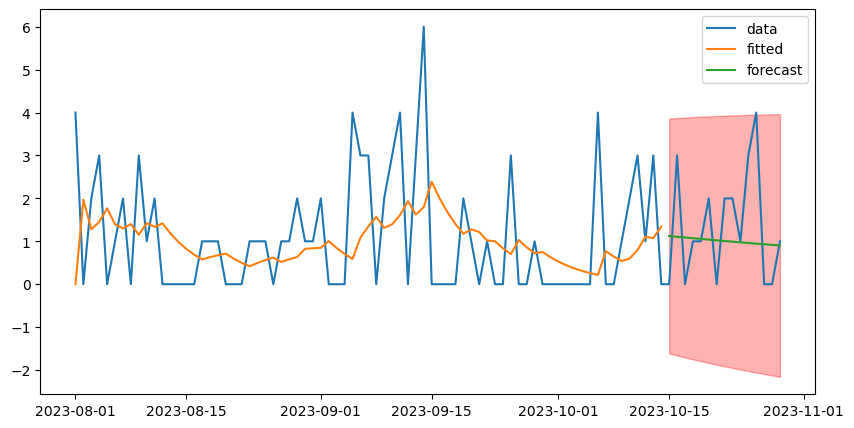

In [51]:
train_pred = model.predict_in_sample(start=0, end=-1)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(nv.index, nv, label='data')
ax.plot(train.index, train_pred, label='fitted')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
               confint[:,0], confint[:,1], \
               color='red', alpha=0.3)
ax.legend();

In [52]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

In [53]:
nv.columns = ['y']
nv['ds'] = nv.index
nv.head()

,y,ds
Date,,
2023-08-01,4,2023-08-01
2023-08-02,0,2023-08-02
2023-08-03,2,2023-08-03
2023-08-04,3,2023-08-04
2023-08-05,0,2023-08-05


In [55]:
m = Prophet()
m.fit(nv)

21:55:03 - cmdstanpy - INFO - Chain [1] start processing
21:55:03 - cmdstanpy - INFO - Chain [1] done processing


In [56]:
future = m.make_future_dataframe(periods=30, freq='D')
forecast = m.predict(future)

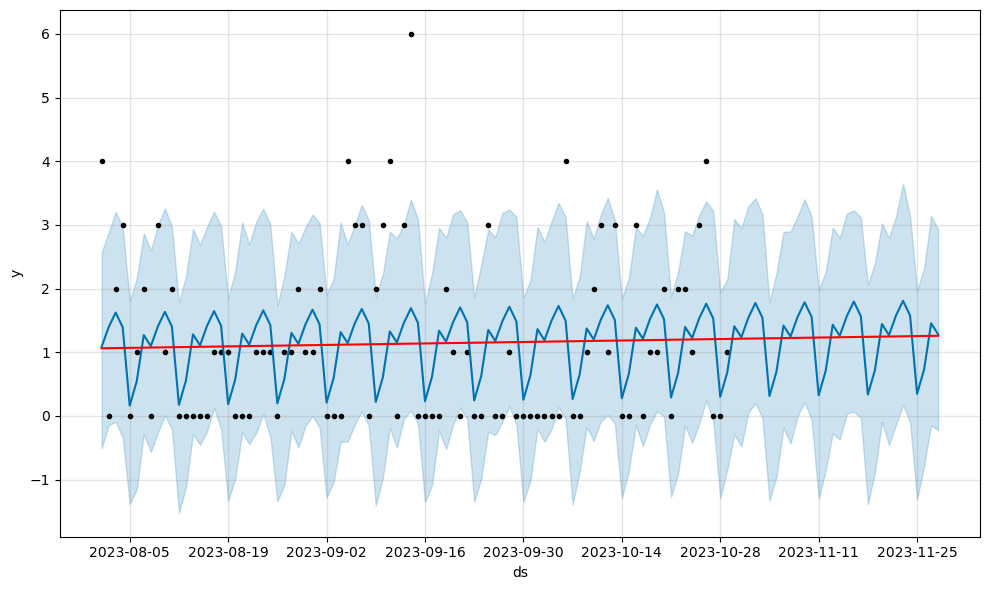

In [57]:
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)